<a href="https://colab.research.google.com/github/nguyenduyvu61107/BTAI-20-4-2026/blob/main/data2/BTAI_20042026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install folium matplotlib pandas geopandas geopy osmnx networkx scikit-learn

In [ ]:
#23.1
import folium
from folium import plugins
ueh_coords = [10.761053418680913, 106.66833573412985]
m = folium.Map(location=ueh_coords, zoom_start=15)
locations = [
    {"name": "UEH - Cơ sở B", "coord": [10.761053418680913, 106.66833573412985], "type": "Trường học"},
    {"name": "Bệnh viện Chợ Rẫy", "coord": [10.757867602104005, 106.65951773733045], "type": "Bệnh viện"},
    {"name": "Công viên Hòa Bình", "coord": [10.760641411530822, 106.67343986311577], "type": "Công viên"},
    {"name": "Vạn Hạnh Mall", "coord": [10.77059586900151, 106.66991206663451], "type": "TT Thương mại"},
    {"name": "Bến xe Chợ Lớn", "coord": [10.751232186471052, 106.65121876049537], "type": "Bến xe"}
]
fg = folium.FeatureGroup(name='Địa điểm công cộng').add_to(m)
for loc in locations:
    folium.Marker(
        location=loc["coord"],
        popup=f"<b>{loc['name']}</b><br>{loc['type']}",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(fg)
folium.LayerControl().add_to(m)
m

In [ ]:
#23.2
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

geolocator = Nominatim(user_agent="my_ai_app", timeout=10)

addresses = [
    "Dinh Độc Lập", "Nhà thờ Đức Bà, Quận 1, HCM",
    "Chợ Bến Thành, Quận 1, HCM", "Landmark 81, Bình Thạnh, HCM",
    "Bưu điện Thành phố, Quận 1, HCM", "Bitexco, Quận 1, HCM",
    "Phố Đi Bộ Nguyễn Huệ", "Vạn Hạnh Mall, Quận 10, HCM",
    "Bệnh Viện Từ Dũ", "Thảo Cầm Viên, Quận 1, HCM"
]

center_point = (10.761053418680913, 106.66833573412985)

m2 = folium.Map(location=center_point, zoom_start=13)

for addr in addresses:
    location = geolocator.geocode(addr)
    if location:
        point = (location.latitude, location.longitude)
        dist = geodesic(center_point, point).km
        print(f"{addr}: {point} - Cách UEH B: {dist:.2f} km")
        folium.Marker(point, popup=f"{addr}: {dist:.2f}km").add_to(m2)
        folium.PolyLine([center_point, point], color="red", weight=2, opacity=0.5).add_to(m2)
    else:
        print(f"Không xác định đc toạ độ: {addr}")

m2

Dinh Độc Lập: (10.7770348, 106.695488) - Cách UEH B: 3.46 km
Nhà thờ Đức Bà, Quận 1, HCM: (10.7797687, 106.6990427) - Cách UEH B: 3.95 km
Chợ Bến Thành, Quận 1, HCM: (10.7797687, 106.6990427) - Cách UEH B: 3.95 km
Landmark 81, Bình Thạnh, HCM: (10.7969577, 106.7504543) - Cách UEH B: 9.82 km
Bưu điện Thành phố, Quận 1, HCM: (10.7799557, 106.6999921) - Cách UEH B: 4.04 km
Bitexco, Quận 1, HCM: (10.7718634, 106.7044633) - Cách UEH B: 4.13 km
Phố Đi Bộ Nguyễn Huệ: (10.7754135, 106.7001378) - Cách UEH B: 3.82 km
Vạn Hạnh Mall, Quận 10, HCM: (10.7704843, 106.6695631) - Cách UEH B: 1.05 km
Bệnh Viện Từ Dũ: (10.7687267, 106.6858975) - Cách UEH B: 2.10 km
Thảo Cầm Viên, Quận 1, HCM: (10.7878424, 106.7063352) - Cách UEH B: 5.10 km


In [ ]:
#23.3
import numpy as np
from folium.plugins import HeatMap
data = (np.random.normal(size=(100, 2)) * 0.01 + ueh_coords).tolist()
m3 = folium.Map(location=ueh_coords, zoom_start=14)
HeatMap(data).add_to(m3)
m3

# Ý nghĩa quản trị:
# -Với dữ liệu được chọn để giả lập là mức độ tập trung
# của khách hàng, các vùng màu đỏ đậm trên bản đồ thể hiện nơi có mật độ
# khách hàng hoặc đơn hàng cao nhất. Trong quản trị, đây là 1 căn cứ để ưu
# tiên phân bổ nguồn lực như nhân viên giao hàng hoặc các chi nhánh.
# -Dựa vào vùng nóng, doanh nghiệp có thể quyết định đặt thêm các trạm
# trung chuyển hoặc cửa hàng phụ để giảm thời gian giao hàng và chi phí vận chuyển.
# -Những khu vực màu xanh hoặc không có màu ám chỉ nơi đang bị bỏ qua hoặc hiệu quả
# kinh doanh thấp, giúp nhà quản trị đưa ra chiến lược mở rộng thị trường
#  hoặc kiểm tra lại lý do tại sao mật độ khách hàng ở đó thấp.


In [ ]:
import folium
ueh_b = [10.761053418680913, 106.66833573412985]
#23.5
m5 = folium.Map(location=ueh_b, zoom_start=11)
radii = [3000, 5000, 10000]
colors = ['green', 'orange', 'red']
for radius, color in zip(radii, colors):
    folium.Circle(
        location=ueh_b,
        radius=radius,
        color=color,
        fill=True,
        fill_opacity=0.2,
        popup=f"Vùng {radius/1000}km"
    ).add_to(m5)
folium.Marker(ueh_b, popup="Trung tâm phân phối").add_to(m5)
m5

# Có thể thấy khả năng tiếp cận khách hàng sẽ giảm dần khi nằm trong vùng có bán kính vùng phục vụ tăng dần,
# trong khi đó khu vực trung tâm cho phép khả năng hoạt động và giao hàng thường xuyên với quãng đường ngắn
# và chi phí thấp hơn.
# Do đó phạm vi hoạt động tối ưu nằm trong vùng trung tâm biểu diễn bởi vòng tròn xanh.

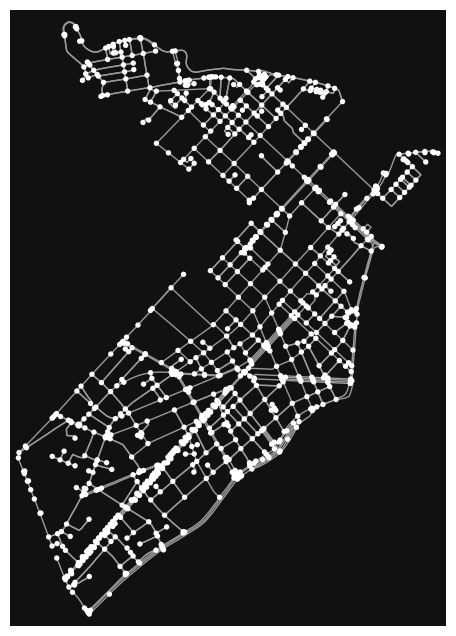

Số lượng nút giao (Intersection): 989
Số lượng đoạn đường: 2090
Chiều dài đường trung bình: 79.03 m
Mật độ mạng lưới: 270.73 edges/km2


In [ ]:
#23.6
import osmnx as ox
place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')
ox.plot_graph(G)
nodes_count = len(G.nodes)
edges_count = len(G.edges)
edges_df = ox.graph_to_gdfs(G, nodes=False)
avg_length = edges_df["length"].mean()
area_km2 = 7.72
network_density = edges_count / area_km2
print(f"Số lượng nút giao (Intersection): {nodes_count}")
print(f"Số lượng đoạn đường: {edges_count}")
print(f"Chiều dài đường trung bình: {avg_length:.2f} m")
print(f"Mật độ mạng lưới: {network_density:.2f} edges/km2")

# Dữ liệu mạng lưới từ OSMnx đóng vai trò quan trọng trong các hệ thống AI đô thị, giúp chuyển hóa
# bản đồ thực tế thành cấu trúc đồ thị để máy tính có thể xử lý. Nhờ đó, nhà quản trị có thể ứng dụng
# AI vào việc tối ưu hóa luồng giao thông, lập kế hoạch vận tải chính xác theo thời gian thực
# và đánh giá mật độ hạ tầng để phân bổ các dịch vụ công cộng một cách khoa học và hiệu quả nhất.

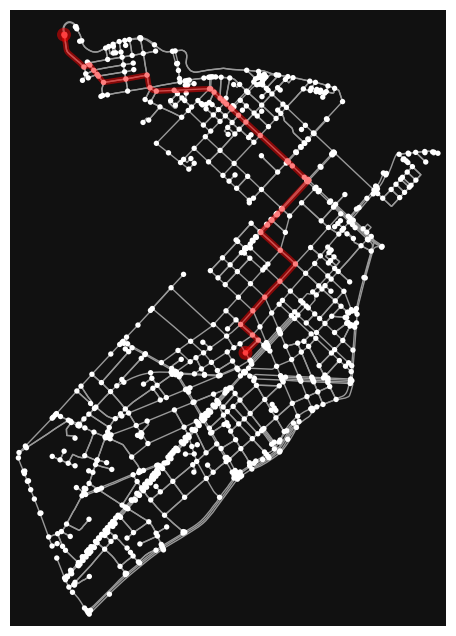

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
#23.7
import osmnx as ox
import networkx as nx
G = ox.graph_from_place("District 1, Ho Chi Minh City, Vietnam", network_type='drive')
orig = ox.geocode("Ben Thanh Market, Ho Chi Minh City, Vietnam")
dest = ox.geocode("Tan Son Nhat Airport, Ho Chi Minh City, Vietnam")
orig_node = ox.distance.nearest_nodes(G, orig[1], orig[0])
dest_node = ox.distance.nearest_nodes(G, dest[1], dest[0])
route = nx.shortest_path(G, orig_node, dest_node, weight='length')
ox.plot_graph_route(G, route)

# Cả 2 phương pháp đều có độ chính xác tương đương, nhưg trong khi Dijkstra tìm đường bằng cách
# quét theo, thì A* quét 1 cách có định hướng dựa trên hàm Heuristic giúp tăng tốc độ xử lý vượt trội
# và tối ưu tài nguyên. Đối với nhà quản trị, A* là lựa chọn hợp lý hơn cho các hệ thống gọi xe
# và logistics thời gian thực nhờ khả năng phản hồi nhanh, đảm bảo độ chính xác mà vẫn tiết kiệm
# chi phí vận hành hệ thống.

In [ ]:
#23.8
import folium
import numpy as np
from scipy.spatial import distance
center_coords = [10.7769, 106.7009]
m8 = folium.Map(location=center_coords, zoom_start=15)
np.random.seed(42)
cars = np.random.normal(size=(5, 2)) * 0.005 + center_coords
customers = np.random.normal(size=(3, 2)) * 0.005 + center_coords
assignments = []
for cust in customers:
    dists = [distance.euclidean(cust, car) for car in cars]
    closest_car_idx = np.argmin(dists)
    assignments.append((cust, cars[closest_car_idx]))
for i, cust in enumerate(customers):
    folium.Marker(cust, popup=f"Khách hàng {i+1}",
                  icon=folium.Icon(color='red', icon='user')).add_to(m8)
for i, car in enumerate(cars):
    folium.Marker(car, popup=f"Xe trống {i+1}",
                  icon=folium.Icon(color='blue', icon='car')).add_to(m8)
for cust, car in assignments:
    folium.PolyLine([cust, car], color='green', weight=3, opacity=0.8,
                    dash_array='10', popup="Lộ trình đón khách").add_to(m8)
m8

# Việc áp dụng hàm Heuristic giúp hệ thống đưa ra quyết định gần như ngay lập tức mà không cần
# tính toán quá phức tạp. Trong quản trị logistics, điều này giúp tối ưu hóa thời gian chờ đợi
# của khách hàng, giảm quãng đường xe chạy không tải và tăng hiệu suất phục vụ của đội xe.


In [ ]:
#23.9
import folium
import numpy as np
import random
place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')
nodes_data = list(G.nodes(data=True))
random.seed(42)
customer_nodes = random.sample(nodes_data, 100)
customers = [[data['y'], data['x']] for node, data in customer_nodes]
stations = [
    {"name": "Trạm Trung tâm", "pos": [10.7769, 106.7009], "color": "orange"},
    {"name": "Trạm phía Bắc (Đa Kao)", "pos": [10.7890, 106.6980], "color": "green"},
    {"name": "Trạm phía Nam (Cô Giang)", "pos": [10.7650, 106.6950], "color": "blue"},
]
m9 = folium.Map(location=[10.7769, 106.7009], zoom_start=14)
for cust in customers:
    folium.CircleMarker(
        location=cust,
        radius=3,
        color='red',
        fill=True,
        opacity=0.6
    ).add_to(m9)
for st in stations:
    folium.Marker(
        location=st["pos"],
        popup=st["name"],
        icon=folium.Icon(color=st['color'], icon='warehouse', prefix='fa')
    ).add_to(m9)
    folium.Circle(
        location=st["pos"],
        radius=1000,
        color=st['color'],
        fill=True,
        fill_opacity=0.1
    ).add_to(m9)
m9

# Đặt 3 trạm trung chuyển tại các vị trí nằm trên các đường lớn của quận 1
# cũng như bao phủ được phần lớn các khách hàng (chấm đỏ) giúp đạt được sự
# cân bằng giữa chi phí và chất lượng dịch vụ. Mô hình này đảm bảo phần lớn khách hàng
# đều nằm trong bán kính phục vụ lý tưởng (1 đến 2 km), giúp tối ưu thời gian giao hàng
# và quãng đường di chuyển của tài xế. Đồng thời, việc phân tán trạm dựa trên mật độ
# dữ liệu thực tế giúp cân bằng tải nguồn lực, tránh tình trạng quá tải tại một kho duy nhất
# và tạo cơ sở để đưa ra các quyết định thuê mặt bằng kho bãi hiệu quả.

In [ ]:
#23.10
import folium
from folium.plugins import HeatMap
import osmnx as ox
import networkx as nx
G = ox.graph_from_place("District 1, Ho Chi Minh City, Vietnam", network_type='drive')
congestion_points = [
    [10.7719, 106.6983], [10.7725, 106.6990], [10.7710, 106.6975],
    [10.7797, 106.6990], [10.7805, 106.7000]
]
start_lat, start_lng = 10.7680, 106.6910
end_lat, end_lng = 10.7850, 106.7050
start_node = ox.distance.nearest_nodes(G, start_lng, start_lat)
end_node = ox.distance.nearest_nodes(G, end_lng, end_lat)
path_default = nx.shortest_path(G, start_node, end_node, weight='length')
m10 = folium.Map(location=[10.7769, 106.7009], zoom_start=15)
HeatMap(congestion_points, radius=25, blur=15, gradient={0.4: 'yellow', 0.8: 'orange', 1: 'red'}).add_to(m10)
path_default_coords = [[G.nodes[node]['y'], G.nodes[node]['x']] for node in path_default]
folium.PolyLine(path_default_coords, color='black', weight=5, opacity=0.7).add_to(m10)
folium.Marker([10.7680, 106.6910], popup="Điểm đi", icon=folium.Icon(color='green')).add_to(m10)
folium.Marker([10.7850, 106.7050], popup="Điểm đến", icon=folium.Icon(color='red')).add_to(m10)
m10

In [ ]:
#23.11
import folium
from folium.plugins import HeatMap
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import osmnx as ox
import random
G = ox.graph_from_place("District 1, Ho Chi Minh City, Vietnam", network_type='drive')
nodes_data = list(G.nodes(data=True))
data = {
    'hour': [14, 15, 16, 17],
    'demand_count': [50, 80, 150, 220]
}
df = pd.DataFrame(data)
model = LinearRegression()
model.fit(df[['hour']], df['demand_count'])
predicted_demand = int(model.predict([[18]])[0])
random.seed(10)
target_nodes_demand = random.sample(nodes_data, predicted_demand)
forecasted_locations = [[data['y'], data['x']] for node, data in target_nodes_demand]
center_q1 = [10.7769, 106.7009]
m11 = folium.Map(location=center_q1, zoom_start=14)
HeatMap(forecasted_locations, radius=20, blur=15, gradient={0.2: 'green', 0.5: 'orange', 1: 'red'}).add_to(m11)
target_nodes_drivers = random.sample(nodes_data, 30)
for node, data in target_nodes_drivers:
    folium.Marker([data['y'], data['x']], icon=folium.Icon(color='darkblue', icon='motorcycle', prefix='fa')).add_to(m11)
m11

# Phân tích sự khác biệt nhu cầu: Mô hình chỉ ra rằng nhu cầu dịch vụ luôn có sự chênh lệch đáng kể về địa điểm và thời gian,
# tập trung cực đại tại các điểm nóng trung tâm vào các khung giờ cao điểm thay vì phân bổ đều. Sự khác biệt này tạo ra những
# khu vực yêu cầu nguồn lực cao, nơi mật độ khách hàng vượt xa số lượng tài xế hiện có ở vùng rìa, gây áp lực lớn lên hạ tầng
# giao thông và làm tăng khả năng trễ chuyến.

# Ý nghĩa trong điều phối nguồn lực: Việc dự báo được xu hướng giúp chủ động điều phối đón đầu và điều động nguồn lực về vùng
# sắp bùng nổ nhu cầu trước thời điểm xảy ra. Chiến lược này không chỉ tối ưu hóa thu nhập và năng suất cho tài xế bằng cách
# giảm quãng đường chạy trống, mà còn trực tiếp nâng cao trải nghiệm khách hàng thông qua việc rút ngắn thời gian chờ đợi và
# đảm bảo cam kết chất lượng dịch vụ.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 14.1 MB/s eta 0:00:00


/tmp/ipykernel_2661/2920897440.py:61: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(merged.geometry.centroid.x, merged.geometry.centroid.y, merged[COL_DATA]):


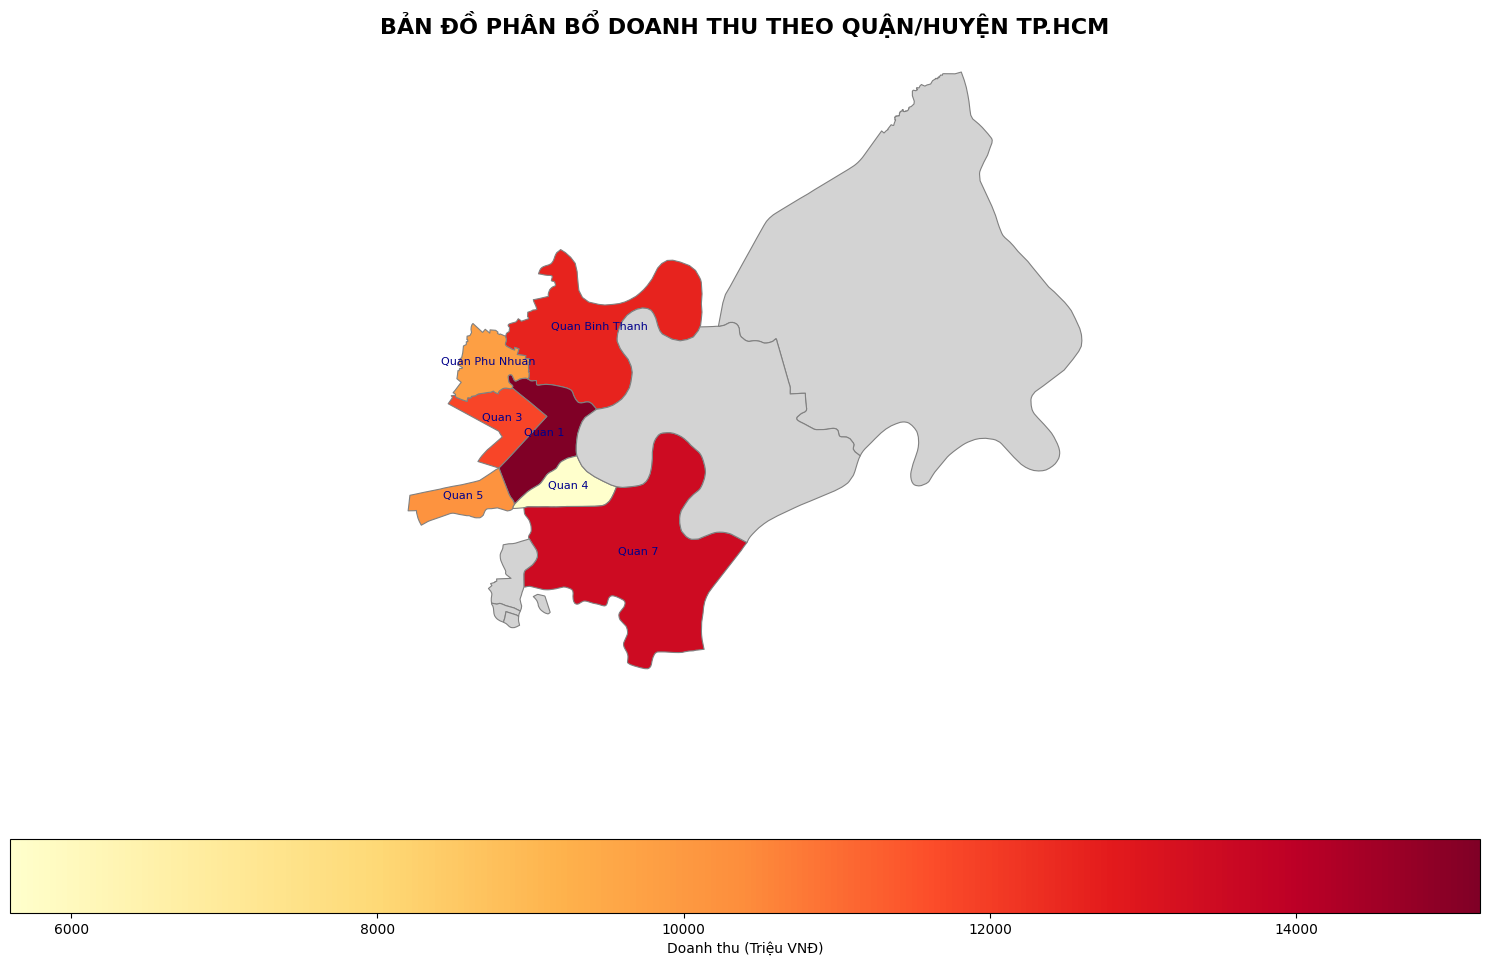

In [ ]:
#23.4
!pip install unidecode
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from unidecode import unidecode
URL_GEOJSON = "https://gist.githubusercontent.com/hoanganh25991/00e8f0162e41ac31ecd7/raw/4a3f501d35cdbe4109635fcc32582f9537e6a502/district-boundary-hcm-city.geojson"

FILE_CSV = "/content/data2.csv"
map_df = gpd.read_file(URL_GEOJSON)
data_df = pd.read_csv(FILE_CSV)
def clean_name(name):
    if isinstance(name, str):
        return unidecode(name).strip().lower()
    return name
COL_MAP = 'localname'
COL_DATA = 'Ten_Quan'
map_df['clean_key'] = map_df[COL_MAP].apply(clean_name)
data_df['clean_key'] = data_df[COL_DATA].apply(clean_name)
merged = map_df.merge(data_df, on='clean_key', how='left')
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
merged.plot(column='Doanh_Thu',
            cmap='YlOrRd',
            linewidth=0.8,
            ax=ax,
            edgecolor='0.5',
            legend=True,
            legend_kwds={'label': "Doanh thu (Triệu VNĐ)", 'orientation': "horizontal"},
            missing_kwds={"color": "lightgrey", "label": "Khong co du lieu"})
for x, y, label in zip(merged.geometry.centroid.x, merged.geometry.centroid.y, merged[COL_DATA]):
    if pd.notnull(label):
        ax.text(x, y, label, fontsize=8, ha='center', color='darkblue')

ax.set_title('BẢN ĐỒ PHÂN BỔ DOANH THU THEO QUẬN/HUYỆN TP.HCM', fontsize=16, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# Bản đồ Choropleth cho thấy sự phân hóa kinh tế theo địa lý tại TP.HCM. Các khu vực trung tâm như
# Quận 1, Quận 7 hiển thị tông màu đỏ đậm, cho thấy mức độ tập trung đơn hàng và doanh thu cao.
# ĐIều này cho thấy cần tối ưu hóa mạng lưới logistics bằng cách đặt các kho trung chuyển gần các
# vùng này để tối ưu thời gian giao hàng, đồng thời cần có chiến lược thâm nhập thị trường riêng biệt
# cho các vùng có màu nhạt để khai phá tiềm năng các khu vực ngoại thành.

In [ ]:
#23.12
import folium
import osmnx as ox
import networkx as nx
import random
G = ox.graph_from_place("District 1, Ho Chi Minh City, Vietnam", network_type='drive')
depots = {
    'Kho A (Dakao)': (10.7890, 106.6990),
    'Kho B (Ben Thanh)': (10.7720, 106.6940)
}

customers = [
    (10.7810, 106.6950), (10.7850, 106.7020), (10.7760, 106.7010),
    (10.7700, 106.6980), (10.7750, 106.6910), (10.7800, 106.7050)
]

depot_nodes = {name: ox.distance.nearest_nodes(G, lon, lat) for name, (lat, lon) in depots.items()}
customer_nodes = [ox.distance.nearest_nodes(G, lon, lat) for lat, lon in customers]
routes = {}
colors = ['blue', 'red']
unvisited = set(customer_nodes)
m12 = folium.Map(location=[10.7769, 106.7009], zoom_start=15)
for (depot_name, start_node), color in zip(depot_nodes.items(), colors):
    current_node = start_node
    route_for_this_depot = [start_node]
    for _ in range(3):
        if not unvisited: break
        next_node = min(unvisited, key=lambda c: nx.shortest_path_length(G, current_node, c, weight='length'))
        path = nx.shortest_path(G, current_node, next_node, weight='length')
        path_coords = [[G.nodes[node]['y'], G.nodes[node]['x']] for node in path]
        folium.PolyLine(path_coords, color=color, weight=5).add_to(m12)
        route_for_this_depot.extend(path[1:])
        unvisited.remove(next_node)
        current_node = next_node
    return_path = nx.shortest_path(G, current_node, start_node, weight='length')
    return_path_coords = [[G.nodes[node]['y'], G.nodes[node]['x']] for node in return_path]
    folium.PolyLine(return_path_coords, color=color, weight=3, opacity=0.6).add_to(m12)
for name, coords in depots.items():
    folium.Marker(coords, popup=name, icon=folium.Icon(color='black', icon='home')).add_to(m12)

for i, coords in enumerate(customers):
    folium.Marker(coords, popup=f"Khách {i+1}", icon=folium.Icon(color='orange')).add_to(m12)
m12

# Quãng đường: Phương án tối ưu giảm được tổng chiều dài di chuyển nhờ việc gom nhóm
# các điểm giao hàng theo cụm địa lý. So với việc giao hàng ngẫu nhiên,
# lộ trình này né được việc xe chạy đan xen chồng chéo giữa các quận.

# Thời gian: Giảm thiểu thời gian xe trống nhờ việc xe quay về kho
# gần nhất ngay sau khi hoàn tất lộ trình.

# Quản trị chi phí: Việc vận hành nhiều kho giúp doanh nghiệp giảm áp lực lên 1 kho trung tâm,
# giảm rủi ro ùn tắc tại điểm xuất phát và tiết kiệm đáng kể chi phí nhiên liệu.

In [8]:
#23.13

import pandas as pd
import geopandas as gpd
import folium
from folium import plugins
from unidecode import unidecode
import numpy as np
import osmnx as ox
import networkx as nx
URL_GEOJSON = "https://gist.githubusercontent.com/hoanganh25991/00e8f0162e41ac31ecd7/raw/4a3f501d35cdbe4109635fcc32582f9537e6a502/district-boundary-hcm-city.geojson"
FILE_CSV = "/content/data2.csv"
try:
    df = pd.read_csv(FILE_CSV)
except:
    print("Lỗi: Không tìm thấy file data2.csv!")
def clean_text(text):
    return unidecode(str(text)).strip().lower()
df['clean_key'] = df['Ten_Quan'].apply(clean_text)
center_hcm = [10.7769, 106.7009]
m13 = folium.Map(location=center_hcm, zoom_start=14, tiles='CartoDB positron')
map_df = gpd.read_file(URL_GEOJSON)
col_name = 'localname' if 'localname' in map_df.columns else 'name'
map_df['clean_key'] = map_df[col_name].apply(clean_text)
for col in map_df.columns:
    if pd.api.types.is_datetime64_any_dtype(map_df[col]):
        map_df[col] = map_df[col].astype(str)
    elif map_df[col].apply(lambda x: isinstance(x, np.ndarray)).any():
        map_df[col] = map_df[col].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
choropleth = folium.Choropleth(
    geo_data=map_df,
    name='Lớp Vùng: Doanh thu Quận/Huyện',
    data=df,
    columns=['clean_key', 'Doanh_Thu'],
    key_on='feature.properties.clean_key',
    fill_color='YlOrRd',
    fill_opacity=0.5,
    line_opacity=0.2,
    legend_name='Doanh thu (Triệu VNĐ)',
    highlight=True
).add_to(m13)
choropleth.geojson.add_child(folium.features.GeoJsonTooltip([col_name], aliases=['Quận: ']))
G = ox.graph_from_place("District 1, Ho Chi Minh City, Vietnam", network_type='drive')
points_data = [
    [10.7890, 106.6990],
    [10.7745, 106.7015],
    [10.7760, 106.7010],
    [10.7720, 106.6940]
]
point_layer = folium.FeatureGroup(name='Lớp Điểm: Nhu cầu dự báo')
route_layer = folium.FeatureGroup(name='Lớp Tuyến: Lộ trình thực tế')
for i, p in enumerate(points_data):
    folium.Marker(location=p, popup=f"Điểm {i+1}", icon=folium.Icon(color='blue', icon='info-sign')).add_to(point_layer)

for i in range(len(points_data) - 1):
    start, end = points_data[i], points_data[i+1]
    orig_node = ox.distance.nearest_nodes(G, start[1], start[0])
    dest_node = ox.distance.nearest_nodes(G, end[1], end[0])
    try:
        route = nx.shortest_path(G, orig_node, dest_node, weight='length')
        route_coords = [[G.nodes[n]['y'], G.nodes[n]['x']] for n in route]
        folium.PolyLine(locations=route_coords, color='darkgreen', weight=5, opacity=0.8).add_to(route_layer)
    except:
        folium.PolyLine(locations=[start, end], color='red', weight=2, dash_array='5').add_to(route_layer)
point_layer.add_to(m13)
route_layer.add_to(m13)
folium.LayerControl(collapsed=False).add_to(m13)
plugins.Fullscreen().add_to(m13)
plugins.MeasureControl(position='topleft').add_to(m13)
m13.save('Dashboard_Thuc_Te_2313.html')
m13

In [18]:
import pandas as pd
import folium
from folium.plugins import TimestampedGeoJson
import osmnx as ox
import networkx as nx
G = ox.graph_from_place('District 1, Ho Chi Minh City, Vietnam', network_type='drive')
m14 = folium.Map(location=[10.7769, 106.7009], zoom_start=15, tiles='CartoDB positron')
depot = [10.7820, 106.7000]
targets = {
    'Target 1': [10.7920, 106.6960], # Đa Kao
    'Target 2': [10.7710, 106.6930], # Chợ Bến Thành
    'Target 3': [10.7799, 106.6999], # Bưu điện Thành phố
    'Target 4': [10.7750, 106.7050]  # Phố đi bộ
}
folium.Marker(depot, popup='KHO TỔNG (HUB)', icon=folium.Icon(color='black', icon='home')).add_to(m14)
for name, coords in targets.items():
    folium.Marker(coords, popup=name, icon=folium.Icon(color='orange', icon='shopping-cart')).add_to(m14)
def get_road_route(start, end):
    orig = ox.distance.nearest_nodes(G, start[1], start[0])
    dest = ox.distance.nearest_nodes(G, end[1], end[0])
    try:
        route = nx.shortest_path(G, orig, dest, weight='length')
        return [[G.nodes[n]['y'], G.nodes[n]['x']] for n in route]
    except nx.NetworkXNoPath:
        print(f"Cảnh báo: Không tìm thấy đường đi giữa {start} và {end}. Bỏ qua lộ trình này.")
        return []
features = []
start_time = pd.Timestamp("2026-04-20 08:00:00")
features = []
start_time = pd.Timestamp("2026-04-20 08:00:00")
for i, (name, target_coords) in enumerate(targets.items()):
    v_id = f"Xe_Tai_{i+1}"
    road_path = get_road_route(depot, target_coords)
    if road_path:
        indices = [int(j * (len(road_path) - 1) / 59) for j in range(60)]
        sampled_path = [road_path[idx] for idx in indices]
        for step_idx, coords in enumerate(sampled_path):
            current_time = start_time + pd.Timedelta(seconds=step_idx * 15)
            features.append({
                'type': 'Feature',
                'geometry': {'type': 'Point', 'coordinates': [coords[1], coords[0]]},
                'properties': {
                    'time': current_time.isoformat(),
                    'icon': 'marker',
                    'iconstyle': {
                        'iconUrl': 'https://img.icons8.com/color/96/truck.png',
                        'iconSize': [35, 35],
                        'iconAnchor': [17, 35]
                    },
                    'popup': f'<b>{v_id}</b>'
                }
            })
TimestampedGeoJson(
    {'type': 'FeatureCollection', 'features': features},
    period='PT15S',
    duration='PT20S',
    add_last_point=True,
    auto_play=True,
    loop=False,
    max_speed=0.05,
    loop_button=True,
    time_slider_drag_update=True
).add_to(m14)
m14.save('Mo_Phong_Sieu_Cham_2314.html')
m14

23.15: HỆ THỐNG ĐIỀU PHỐI GIAO HÀNG ĐA ĐIỂM THÔNG MINH (SMART DISPATCHING SYSTEM)

1.Bài toán:

Trong lĩnh vực Logistics tại các đô thị lớn như TP. Hồ Chí Minh, việc quản lý đội xe giao hàng gặp nhiều thách thức do mạng lưới đường sá phức tạp và tình trạng giao thông không ổn định. Bài toán đặt ra là: Làm thế nào để điều phối đồng thời nhiều phương tiện từ một kho trung tâm đến các điểm tiêu thụ sao cho lộ trình di chuyển là tối ưu nhất về quãng đường và thời gian đồng thời cho phép giám sát viên theo dõi tiến độ một cách trực quan theo thời gian thực.

2.
Dữ liệu sử dụng:

Dữ liệu bản đồ (Geospatial Data): Sử dụng dữ liệu thực tế từ OpenStreetMap thông qua thư viện OSMnx, bao gồm cấu trúc mạng lưới đường đi (nodes và edges) dành cho xe ô tô tại khu vực Quận 1, TP.HCM.
Dữ liệu tọa độ: Các tọa độ thực tế của kho bãi và 4 điểm giao hàng mục tiêu được thiết lập dựa trên tọa độ GPS.
Dữ liệu thời gian: Giả lập dòng thời gian để mô phỏng sự di chuyển của các phương tiện.

3.
Phương pháp AI & Công nghệ sử dụng:

Thuật toán Tìm đường (Search Algorithm): Ứng dụng thuật toán Dijkstra thông qua thư viện NetworkX để tính toán đường đi ngắn nhất trên đồ thị giao thông trọng số.
Snap-to-Road Logic: Sử dụng thuật toán tìm kiếm nút gần nhất để đảm bảo phương tiện luôn di chuyển bám sát mặt đường thực tế.
Trực quan hóa: Sử dụng thư viện Folium và Plugin TimestampedGeoJson để nén thời gian theo tỷ lệ 1:15, giúp quan sát toàn bộ quá trình giao hàng kéo dài 15 phút trong vòng 60 giây.

4.
Giá trị ứng dụng thực tiễn:

Tối ưu hóa vận hành: Giảm thiểu quãng đường di chuyển của đội xe, từ đó tiết kiệm chi phí nhiên liệu và giảm phát thải CO2.
Nâng cao năng suất giám sát: Giám sát viên có thể quản lý đa xe trên cùng một giao diện, phát hiện sớm các điểm nghẽn hoặc sai lệch lộ trình.
Khả năng mở rộng: Hệ thống có thể tích hợp thêm dữ liệu giao thông thời gian thực để trở thành một ứng dụng AI toàn diện cho các đơn vị vận chuyển chuyên nghiệp.

In [22]:
import pandas as pd
import folium
from folium.plugins import TimestampedGeoJson
import osmnx as ox
import networkx as nx
G = ox.graph_from_place('District 1, Ho Chi Minh City, Vietnam', network_type='drive')
m15 = folium.Map(location=[10.7820, 106.7000], zoom_start=15, tiles='CartoDB positron')
depot = [10.7820, 106.7000]
targets = {
    'Điểm giao 1 (Đa Kao)': [10.7920, 106.6960],
    'Điểm giao 2 (Bến Thành)': [10.7710, 106.6930],
    'Điểm giao 4 (Bến Nghé)': [10.7750, 106.7050]
}
folium.Marker(depot, popup='KHO TỔNG (HUB)', icon=folium.Icon(color='black', icon='home')).add_to(m15)
for name, coords in targets.items():
    folium.Marker(coords, popup=name, icon=folium.Icon(color='orange', icon='shopping-cart')).add_to(m15)

def get_optimized_route(start, end):
    orig = ox.distance.nearest_nodes(G, start[1], start[0])
    dest = ox.distance.nearest_nodes(G, end[1], end[0])
    try:
        route = nx.shortest_path(G, orig, dest, weight='length')
        return [[G.nodes[n]['y'], G.nodes[n]['x']] for n in route]
    except nx.NetworkXNoPath:
        print(f"Cảnh báo: Không tìm thấy đường đi giữa {start} và {end}. Bỏ qua lộ trình này.")
        return []
features = []
start_time = pd.Timestamp("2026-04-20 08:00:00")
for i, (name, target_coords) in enumerate(targets.items()):
    v_id = f"Xe Tai {i+1}"
    road_path = get_optimized_route(depot, target_coords)
    if road_path:
        dist = nx.shortest_path_length(G, ox.distance.nearest_nodes(G, depot[1], depot[0]),
                                      ox.distance.nearest_nodes(G, target_coords[1], target_coords[0]), weight='length')
        print(f"{v_id}: Lộ trình tối ưu đến {name} dài {dist:.1f}m")
        indices = [int(j * (len(road_path) - 1) / 59) for j in range(60)]
        sampled_path = [road_path[idx] for idx in indices]
        for step_idx, coords in enumerate(sampled_path):
            current_time = start_time + pd.Timedelta(seconds=step_idx * 15)
            features.append({
                'type': 'Feature',
                'geometry': {'type': 'Point', 'coordinates': [coords[1], coords[0]]},
                'properties': {
                    'time': current_time.isoformat(),
                    'icon': 'marker',
                    'iconstyle': {
                        'iconUrl': 'https://img.icons8.com/color/96/truck.png',
                        'iconSize': [35, 35],
                        'iconAnchor': [17, 35]
                    },
                    'popup': f'<b>{v_id}</b><br>Đang giao hàng: {name}'
                }
            })
TimestampedGeoJson(
    {'type': 'FeatureCollection', 'features': features},
    period='PT15S',
    duration='PT20S',
    add_last_point=True,
    auto_play=True,
    loop=False,
    max_speed=0.2,
    loop_button=True,
    time_slider_drag_update=True
).add_to(m15)
m15.save('Applog2315.html')
m15

Xe Tai 1: Lộ trình tối ưu đến Điểm giao 1 (Đa Kao) dài 1577.9m
Xe Tai 2: Lộ trình tối ưu đến Điểm giao 2 (Bến Thành) dài 1943.0m
Xe Tai 3: Lộ trình tối ưu đến Điểm giao 4 (Bến Nghé) dài 1071.9m
